Author Lingting Shi, from Elham Azizi lab
Functions of this notebook is written by Zicheng Wang from Yufeng Shen lab from https://github.com/princello/TCRB_matching

In [1]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import seaborn as sns
import os
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROJECT_ROOT = Path('../..')

# Input paths
ALLCLONES_ALL_PATH     = PROJECT_ROOT / 'adata_file' / 'AllClones_2.csv'
TCELL_ANN_CONCAT_REFINED_PATH = PROJECT_ROOT / 'adata_file' / 'tcell_ann_concat_Tcell_only_Migration_refined.h5ad'
TCR_DATA_PATH    = PROJECT_ROOT / 'adata_file' / 'McPAS-TCR-2.csv'
TCR_SEL_ALL_PATH              = PROJECT_ROOT / 'adata_file' / 'tcr_sel_all.csv'

# export shared clones
ALLO_SHARED_CLONES_PATH = PROJECT_ROOT / 'adata_file' / 'Alloreactive_shared_clones_McPAS.csv'
NON_ALLO_SHARED_CLONES_PATH = PROJECT_ROOT / 'adata_file' / 'Non_alloreactive_shared_clones_McPAS.csv'


In [3]:
#Load adaptive alloreactive clone info
adaptive_all = pd.read_csv(ALLCLONES_ALL_PATH)

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_6919/3733659529.py:2: DtypeWarning: Columns (9,11,27,29) have mixed types. Specify dtype option on import or set low_memory=False.
  adaptive_all = pd.read_csv(ALLCLONES_ALL_PATH)


In [4]:
len(adaptive_all[adaptive_all['allo'] == True]['cdr3_amino_acid'].unique())

47719

In [5]:
len(adaptive_all[adaptive_all['allo'] == False]['cdr3_amino_acid'].unique())

1827929

In [6]:
# read
McPAS_TCR = pd.read_csv(TCR_DATA_PATH)

/var/folders/08/j2wbrltj24qcpm1vfvrsrkgh0000gq/T/ipykernel_6919/2318128699.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  McPAS_TCR = pd.read_csv(TCR_DATA_PATH)


In [7]:
McPAS_TCR.head()

,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,Single.cell,NGS,...,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
0,NaN,ATSIRFTDTQYF,Human,Autoimmune,Celiac disease,D002503,6 days post oral gluten\nchallenge,1.0,Yes,Yes,...,TRAV8-6,NaN,TRBV7-2,NaN,TRBJ2-3,NaN,NaN,NaN,23878218,NaN
1,NaN,CAAAAASGAYEQYF,Human,Pathogens,M.Tuberculosis,D009169,Bulk,2.2,No,Yes,...,NaN,NaN,TRBV10-3,NaN,NaN,NaN,NaN,NaN,32341563,NaN
2,NaN,CAAADEEIGNQPQHF,Human,Pathogens,Hepatitis C virus,D016174,NaN,1.0,No,No,...,NaN,NaN,TRBV10-03,NaN,NaN,No,NaN,NaN,21160049,NaN
3,CAVRDSNYQLIW,CAAAGGPDTGELFF,Human,Pathogens,M. tuberculosis,D009169,NaN,2.2,Yes,Yes,...,NaN,TRAJ33,TRBV6-1,NaN,TRBJ2-2,NaN,NaN,NaN,30992377,NaN
4,NaN,CAAEDDTGGFKTIF,Human,Pathogens,Influenza,D009980,NaN,1.0,Yes,Yes,...,TRAV8-4:03,TRAJ45:01,TRBV25:01,NaN,TRBJ9:01,No,NaN,NaN,28300170,NaN


In [8]:
len(McPAS_TCR)

40731

In [9]:
len(McPAS_TCR['CDR3.beta.aa'].unique())

32183

In [10]:
# shared clones between mcPAS_TCR and adaptive_all
shared_clones = McPAS_TCR[McPAS_TCR['CDR3.beta.aa'].isin(adaptive_all[adaptive_all['allo'] == True]['cdr3_amino_acid'])]


In [11]:
# shared clones between mcPAS_TCR and adaptive_all
non_allo_shared_clones = McPAS_TCR[McPAS_TCR['CDR3.beta.aa'].isin(adaptive_all[adaptive_all['allo'] == False]['cdr3_amino_acid'])]

In [12]:
# export shared clones
shared_clones.to_csv(ALLO_SHARED_CLONES_PATH, index=False)
non_allo_shared_clones.to_csv(NON_ALLO_SHARED_CLONES_PATH, index=False)

In [13]:
len(shared_clones['CDR3.beta.aa'].unique())/len(adaptive_all[adaptive_all['allo'] == True]['cdr3_amino_acid'].unique())

0.01259456401014271

In [14]:
len(shared_clones['CDR3.beta.aa'].unique())

601

In [15]:
len(non_allo_shared_clones['CDR3.beta.aa'].unique())/len(adaptive_all[adaptive_all['allo'] == False]['cdr3_amino_acid'].unique())

0.0030564644469232667

In [16]:
len(non_allo_shared_clones['CDR3.beta.aa'].unique())

5587

In [17]:
non_allo_shared_clones

,CDR3.alpha.aa,CDR3.beta.aa,Species,Category,Pathology,Pathology.Mesh.ID,Additional.study.details,Antigen.identification.method,Single.cell,NGS,...,TRAV,TRAJ,TRBV,TRBD,TRBJ,Reconstructed.J.annotation,CDR3.beta.nt,Mouse.strain,PubMed.ID,Remarks
13,NaN,CAAGTGDSNQPQHF,Human,Pathogens,Cytomegalovirus (CMV),D003586,NaN,1.0,No,Yes,...,NaN,NaN,TRBV10-3,NaN,TRBJ1-5,NaN,NaN,NaN,30587531,NaN
138,NaN,CAGGRHSYEQYF,Human,Pathogens,M.Tuberculosis,D009169,Bulk,2.2,No,Yes,...,NaN,NaN,TRBV30,NaN,NaN,NaN,NaN,NaN,32341563,NaN
291,CAPFYSSASKIIF,CAIGLAEDTQYF,Human,Pathogens,M.Tuberculosis,D009169,NaN,2.2,Yes,Yes,...,TRAV6,TRAJ3,TRBV10-3,NaN,TRBJ2-3,NaN,NaN,NaN,32341563,NaN
293,CAVAPSGGSYIPTF,CAIGNTGELFF,Human,Pathogens,M.Tuberculosis,D009169,NaN,2.2,Yes,Yes,...,TRAV8-3,TRAJ6,TRBV3-1,NaN,TRBJ2-2,NaN,NaN,NaN,32341563,NaN
297,NaN,CAIGTGDSNQPQHF,Human,Cancer,Lung cancer,D008175,Vaccination,1.0,No,No,...,NaN,NaN,NaN,NaN,TRBJ1-5,No,NaN,NaN,26291626,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39949,NaN,CASSPSYEQYF,Human,Autoimmune,Biliary atresia,D001656,Infants,3.0,No,Yes,...,NaN,NaN,TRBV28*01,NaN,TRBJ2-7*01,NaN,NaN,NaN,35004747,NaN
39951,NaN,CASSLGGYEQYF,Human,Autoimmune,Biliary atresia,D001656,Infants,3.0,No,Yes,...,NaN,NaN,TRBV7-9*02,NaN,TRBJ2-7*01,NaN,NaN,NaN,35004747,NaN
39954,NaN,CASSLGEAQYF,Human,Autoimmune,Biliary atresia,D001656,Infants,3.0,No,Yes,...,NaN,NaN,TRBV28*01,NaN,TRBJ2-5*01,NaN,NaN,NaN,35004747,NaN
39957,NaN,CASSFSYEQYF,Human,Autoimmune,Biliary atresia,D001656,Infants,3.0,No,Yes,...,NaN,NaN,TRBV7-2*04,NaN,TRBJ2-7*01,NaN,NaN,NaN,35004747,NaN


<Axes: title={'center': 'Pathology Distribution of Alloreactive Clones'}>

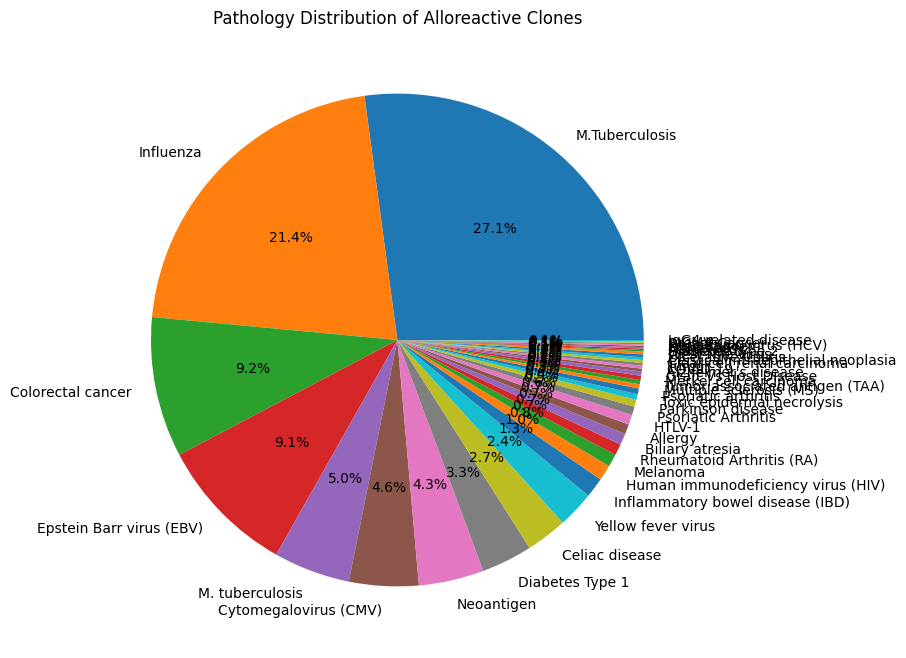

In [18]:
# plot pie chart of pathology
pathology_counts = shared_clones['Pathology'].value_counts()
pathology_counts.plot.pie(autopct='%1.1f%%', figsize=(8, 8), title='Pathology Distribution of Alloreactive Clones', ylabel='')

<Axes: title={'center': 'Pathology Distribution of NonAlloreactive Clones'}>

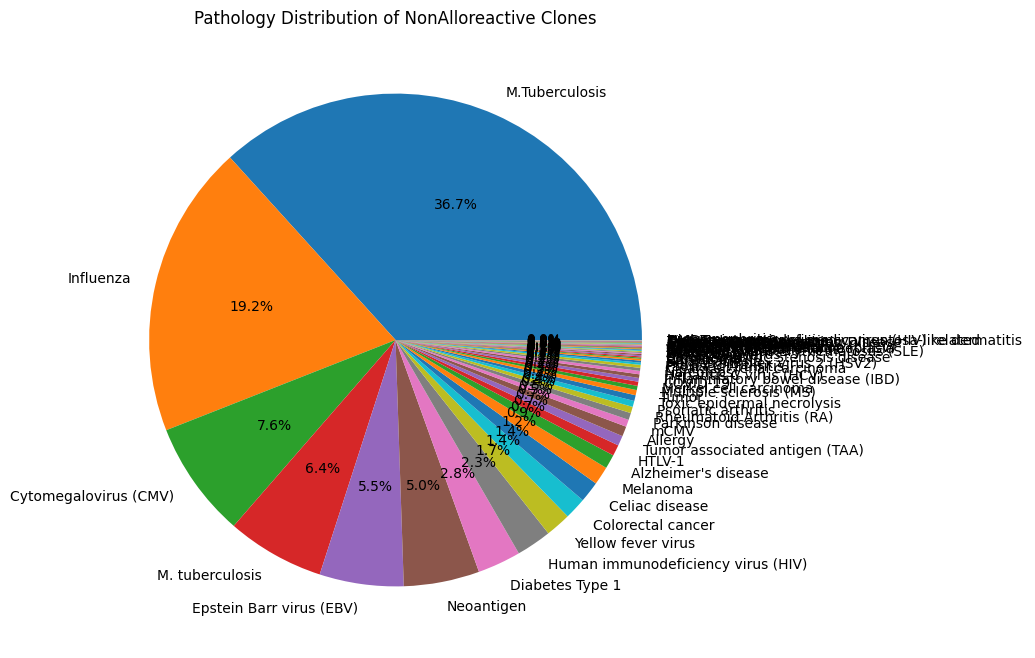

In [19]:
# plot pie chart of pathology
pathology_counts = non_allo_shared_clones['Pathology'].value_counts()
pathology_counts.plot.pie(autopct='%1.1f%%', figsize=(8, 8), title='Pathology Distribution of NonAlloreactive Clones', ylabel='')

In [20]:
# Look at Influenza, EBV, CMV proportions in different GVHD grades
shared_clones_infect = shared_clones[shared_clones['Pathology'].isin(['Influenza', 'Epstein Barr virus (EBV)', 'Cytomegalovirus (CMV)'])]
shared_clones_infect['Pathology'].value_counts()

Pathology
Influenza                   230
Epstein Barr virus (EBV)     98
Cytomegalovirus (CMV)        49
Name: count, dtype: int64

In [21]:
adaptive_allo = adaptive_all[adaptive_all['allo'] == True]
adaptive_shared_clones = adaptive_allo[adaptive_allo['cdr3_amino_acid'].isin(shared_clones_infect['CDR3.beta.aa'])]
adaptive_shared_clones

,Unnamed: 0,rearrangement,cdr3_rearrangement,cdr3_amino_acid,v_resolved,j_resolved,templates,frequency,PatientID,timepoint,...,HLA_mis,DLI_PTD,Relapse,Off Immunosuppresion,GVHD_DX_Post_Transplant,GVHD Max Grade Post Transplant,EBV +,HHV6 +,Systemic_Steroids,CMV +
163,164,AATCTTCACATCAATTCCCTGGAGCTTGGTGACTCTGCTGTGTATT...,TGTGCCAGCAGCCTCTCCTACGAGCAGTACTTC,CASSLSYEQYF,TRBV3,TRBJ2-7,0,0.0,R051,039Colon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
186,187,CTGATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCT...,TGTGCCAGCAGTTCGACAGGCTACGAGCAGTACTTC,CASSSTGYEQYF,TRBV27-1,TRBJ2-7,0,0.0,R051,039Colon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
655,656,AGGCTGCTGTCGGCTGCTCCCTCCCAGACATCTGTGTACTTCTGTG...,TGTGCCAGCAGTTACTCGGGGAACACTGAAGCTTTCTTT,CASSYSGNTEAFF,TRBV6-5,TRBJ1-1,0,0.0,R051,039Colon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
669,670,ATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACTTCTGTG...,TGTGCCAGCAGTTTAGGGACCAGCTACGAGCAGTACTTC,CASSLGTSYEQYF,TRBV27-1,TRBJ2-7,0,0.0,R051,039Colon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
701,702,GTGAACGCCTTGTTGCTGGGGGACTCGGCCCTGTATCTCTGTGCCA...,TGTGCCAGCAGCTCGACAGGGCTTAACACTGAAGCTTTCTTT,CASSSTGLNTEAFF,TRBV5-5,TRBJ1-1,0,0.0,R051,039Colon,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539203,539204,CCCCTGATCCTGGAGTCGCCCAGCCCCAACCAGACCTCTCTGTACT...,TGTGCCAGCAGTTTATCCTACGAGCAGTACTTC,CASSLSYEQYF,TRBV27-1,TRBJ2-7,0,0.0,R179,unstimulated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539251,539252,NCTCTCACTGTGACATCGGCCCAAAAGAACCCGACAGCTTTCTATC...,TGTGCCAGTAGTATTGGGAGCGAGCAGTACTTC,CASSIGSEQYF,TRBV19-1,TRBJ2-7,0,0.0,R179,unstimulated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539798,539799,ATTCTGGAGTCCGCCAGCACCAACCAGACATCTATGTACCTCTGTG...,TGTGCCAGCAGTTTACGGAGCACAGATACGCAGTATTTT,CASSLRSTDTQYF,TRBV28-1,TRBJ2-3,0,0.0,R179,unstimulated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539862,539863,CAGCCTGCAAAGCTTGAGGACTCGGCCGTGTATCTCTGTGCCAGCA...,TGTGCCAGCAGCCCCCGTGGCGGCGCCTACAATGAGCAGTTCTTC,CASSPRGGAYNEQFF,TRBV11-2,TRBJ2-1,0,0.0,R179,unstimulated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Category Distribution of Alloreactive Clones'}>

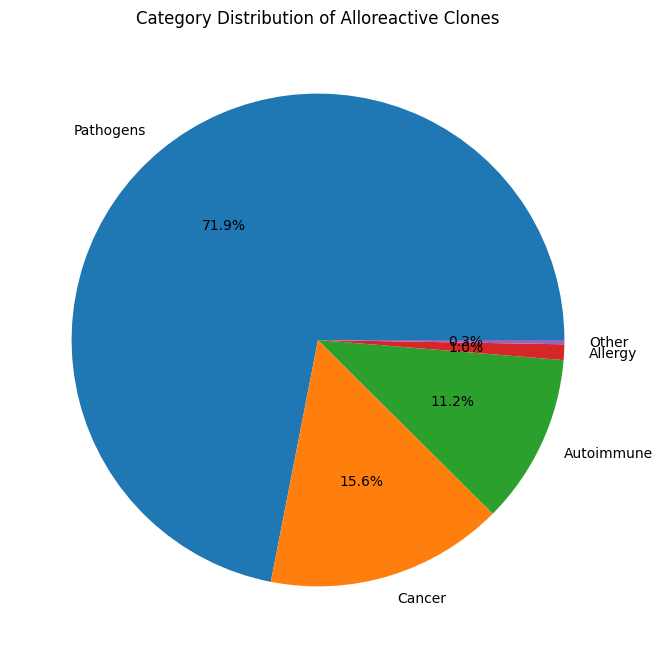

In [22]:
# plot pie chart of category
category_counts = shared_clones['Category'].value_counts()
category_counts.plot.pie(autopct='%1.1f%%', figsize=(8, 8), title='Category Distribution of Alloreactive Clones', ylabel='')